# A/B Testing Framework

## Objective
To statistically compare different content and posting strategies and determine
whether observed differences in engagement are likely to be meaningful rather
than due to random variation.

The available dataset supports comparisons based on content length,
media presence, and posting time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv(
    "cleaned_social_media_engagement_dataset.csv",
    parse_dates=["Timestamp"]
)

df.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,...,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified,Month,Total_Interactions
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,...,1,Monday,16,985,Positive,Macro,True,False,2024-01,8605
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,...,5,Monday,9,627,Negative,Macro,False,True,2024-01,2124
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,...,9,Monday,27,79,Positive,Macro,True,True,2024-01,2084
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,...,10,Monday,17,554,Neutral,Macro,True,False,2024-01,1886
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,...,13,Monday,5,1136,Positive,Mid-tier,True,False,2024-01,10470


In [2]:
median_length = df["Content_Length"].median()

print("Median Content Length:", median_length)

Median Content Length: 549.0


In [3]:
df["Length_Group"] = np.where(
    df["Content_Length"] <= median_length,
    "Short",
    "Long"
)

df["Length_Group"].value_counts()

Length_Group
Short    2505
Long     2495
Name: count, dtype: int64

In [4]:
length_summary = (
    df.groupby("Length_Group")["Engagement_Rate"]
      .agg(["count", "mean", "median"])
)

length_summary

,count,mean,median
Length_Group,,,
Long,2495,6.460289,1.72
Short,2505,17.438052,3.33


### Statistical Significance Test: Short vs Long Content

Because Engagement Rate contains extreme values and is not normally distributed,
the non-parametric Mann–Whitney U test is used to compare engagement between
Short and Long content.

**Hypotheses:**

- H0: There is no significant difference in engagement between Short and Long content.
- H1: There is a significant difference in engagement between Short and Long content.

A significance level of 0.05 is used.

In [5]:
short_engagement = df.loc[
    df["Length_Group"] == "Short",
    "Engagement_Rate"
]

long_engagement = df.loc[
    df["Length_Group"] == "Long",
    "Engagement_Rate"
]

u_stat, p_value = stats.mannwhitneyu(
    short_engagement,
    long_engagement,
    alternative="two-sided"
)

print("Mann-Whitney U Statistic:", round(u_stat, 2))
print("P-value:", p_value)

Mann-Whitney U Statistic: 3982143.5
P-value: 2.648904668150712e-63


In [6]:
alpha = 0.05

if p_value < alpha:
    print("Result: Statistically significant difference.")
    print("Reject the null hypothesis (H0).")
else:
    print("Result: No statistically significant difference.")
    print("Fail to reject the null hypothesis (H0).")

Result: Statistically significant difference.
Reject the null hypothesis (H0).


**Observation:**  
The Mann–Whitney U test produced a p-value far below the 0.05 significance
threshold. Therefore, the null hypothesis is rejected.

Short content has a median engagement rate of 3.33%, compared with 1.72% for
Long content. This indicates a statistically significant association between
shorter content and higher engagement in this dataset.

However, this result represents an association and does not by itself prove
that shorter content causes higher engagement.

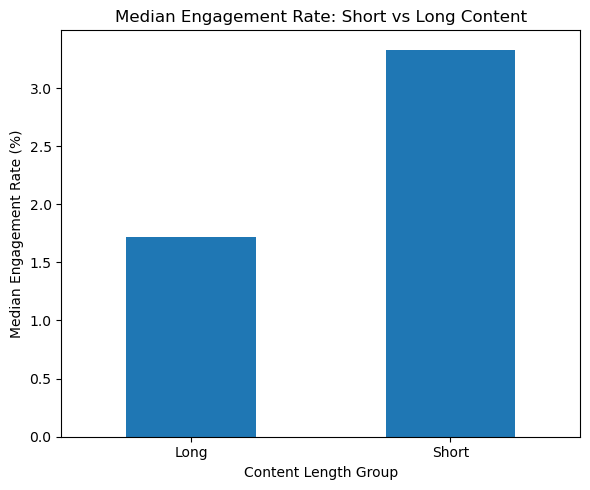

In [7]:
length_summary["median"].plot(
    kind="bar",
    figsize=(6, 5)
)

plt.title("Median Engagement Rate: Short vs Long Content")
plt.xlabel("Content Length Group")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### A/B Test 2: Media vs No Media

This test compares engagement rates between posts that contain media
and posts that do not contain media.

**Hypotheses:**

- H0: There is no significant difference in engagement between posts with media and posts without media.
- H1: There is a significant difference in engagement between posts with media and posts without media.

A significance level of 0.05 is used.

In [8]:
media_summary = (
    df.groupby("Has_Media")["Engagement_Rate"]
      .agg(["count", "mean", "median"])
)

media_summary

,count,mean,median
Has_Media,,,
False,775,15.618065,2.11
True,4225,11.289169,2.35


In [9]:
media_engagement = df.loc[
    df["Has_Media"] == True,
    "Engagement_Rate"
]

no_media_engagement = df.loc[
    df["Has_Media"] == False,
    "Engagement_Rate"
]

In [10]:
u_stat_media, p_value_media = stats.mannwhitneyu(
    media_engagement,
    no_media_engagement,
    alternative="two-sided"
)

print("Mann-Whitney U Statistic:", round(u_stat_media, 2))
print("P-value:", p_value_media)

Mann-Whitney U Statistic: 1674744.5
P-value: 0.30930600788828766


In [11]:
alpha = 0.05

if p_value_media < alpha:
    print("Result: Statistically significant difference.")
    print("Reject the null hypothesis (H0).")
else:
    print("Result: No statistically significant difference.")
    print("Fail to reject the null hypothesis (H0).")

Result: No statistically significant difference.
Fail to reject the null hypothesis (H0).


**Observation:**  
Posts containing media have a slightly higher median engagement rate
(2.35%) than posts without media (2.11%).

However, the Mann–Whitney U test produced a p-value of approximately 0.309,
which is greater than the 0.05 significance threshold. Therefore, the null
hypothesis is not rejected.

The observed difference is not statistically significant, meaning that the
available data does not provide sufficient evidence that media presence alone
is associated with different engagement levels.

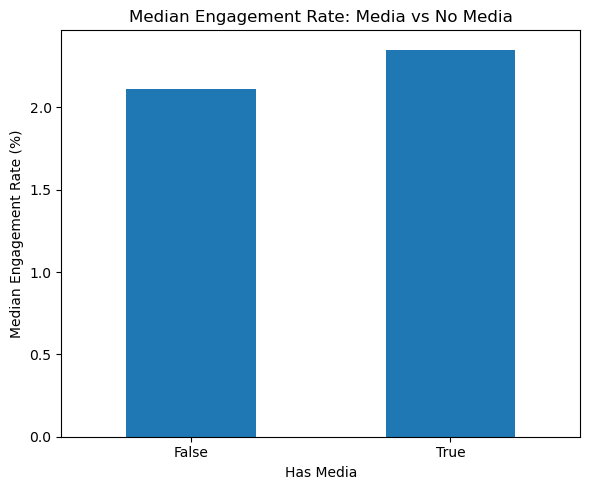

In [12]:
media_summary["median"].plot(
    kind="bar",
    figsize=(6, 5)
)

plt.title("Median Engagement Rate: Media vs No Media")
plt.xlabel("Has Media")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### A/B Test 3: Posting Time

This test examines whether engagement rates differ significantly across
different posting time periods.

**Hypotheses:**

- H0: Engagement rates are similar across all posting time periods.
- H1: At least one posting time period has a significantly different engagement rate.

Since more than two independent groups are being compared and Engagement Rate
is highly skewed, the Kruskal–Wallis test is used.

A significance level of 0.05 is used.

In [13]:
df["Time_Period"] = pd.cut(
    df["Hour_of_Day"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=[
        "Late Night",
        "Morning",
        "Afternoon",
        "Evening",
        "Night"
    ]
)

df["Time_Period"].value_counts().sort_index()

Time_Period
Late Night    1254
Morning       1219
Afternoon     1053
Evening        824
Night          650
Name: count, dtype: int64

In [14]:
time_summary = (
    df.groupby(
        "Time_Period",
        observed=True
    )["Engagement_Rate"]
    .agg(["count", "mean", "median"])
)

time_summary

,count,mean,median
Time_Period,,,
Late Night,1254,11.197974,2.110
Morning,1219,14.454241,2.170
Afternoon,1053,10.323238,2.520
Evening,824,14.360097,2.375
Night,650,8.362569,2.330


In [15]:
late_night = df.loc[
    df["Time_Period"] == "Late Night",
    "Engagement_Rate"
]

morning = df.loc[
    df["Time_Period"] == "Morning",
    "Engagement_Rate"
]

afternoon = df.loc[
    df["Time_Period"] == "Afternoon",
    "Engagement_Rate"
]

evening = df.loc[
    df["Time_Period"] == "Evening",
    "Engagement_Rate"
]

night = df.loc[
    df["Time_Period"] == "Night",
    "Engagement_Rate"
]

h_stat, p_value_time = stats.kruskal(
    late_night,
    morning,
    afternoon,
    evening,
    night
)

print("Kruskal-Wallis H Statistic:", round(h_stat, 2))
print("P-value:", p_value_time)

Kruskal-Wallis H Statistic: 6.59
P-value: 0.1593640907586669


In [16]:
alpha = 0.05

if p_value_time < alpha:
    print("Result: Statistically significant difference.")
    print("Reject the null hypothesis (H0).")
else:
    print("Result: No statistically significant difference.")
    print("Fail to reject the null hypothesis (H0).")

Result: No statistically significant difference.
Fail to reject the null hypothesis (H0).


**Observation:**  
Afternoon posts show the highest median engagement rate (2.52%), while
Late Night posts show the lowest (2.11%).

However, the Kruskal–Wallis test produced a p-value of approximately 0.159,
which is greater than the 0.05 significance threshold. Therefore, the null
hypothesis is not rejected.

The available data does not provide sufficient evidence that engagement
differs significantly across the selected posting time periods.

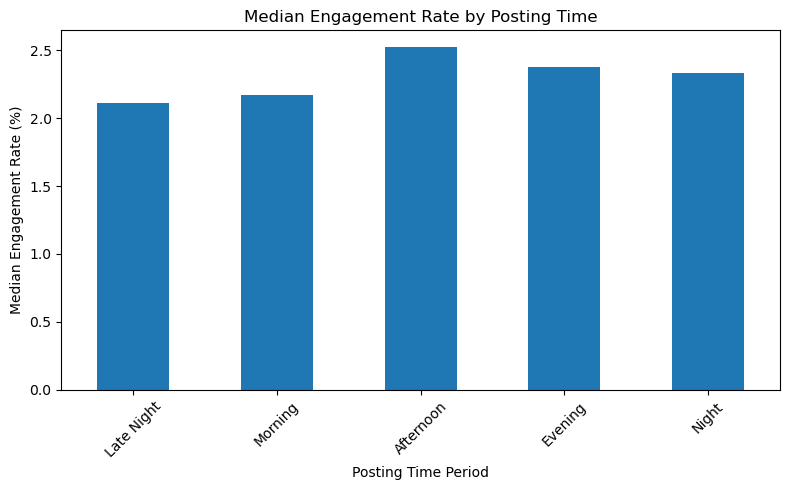

In [17]:
time_summary["median"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Median Engagement Rate by Posting Time")
plt.xlabel("Posting Time Period")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## A/B Testing Summary

The statistical experiments show that content length is the strongest tested
factor associated with engagement. Short content achieved significantly higher
engagement than long content.

Although posts containing media and posts published during certain time periods
showed differences in median engagement, these differences were not statistically
significant at the 0.05 significance level.

Therefore, among the tested variables, content length provides the strongest
evidence for engagement optimization.